# Kalshi Trust Backtest
**Period:** January 1 – March 25, 2026  
**Starting balance:** $10,000  

## Strategy
Rather than fading Kalshi's prices, this strategy **follows** them: when Kalshi prices YES higher than the independent model by ≥5 percentage points, buy YES — trusting that Kalshi's crowd has information the simple model misses. When Kalshi prices YES *lower* than the model by ≥5pp, buy NO (same logic in reverse).

| Parameter | This notebook | Original backtest |
|-----------|--------------|-------------------|
| Direction | Follow Kalshi | Fade Kalshi |
| Min edge | 5 pp | 10 pp |
| Max trades/day | 20 | 4 |
| Budget/trade | $10 | $10 |

**Signal definition:**  
- `kalshi_mid − model_prob > +5pp` → buy YES  
- `kalshi_mid − model_prob < −5pp` → buy NO  

All other mechanics (data sources, matching, price proxy) are identical to `backtest.ipynb`.

In [1]:
import os, re, json, time, base64, datetime, math
from pathlib import Path
from collections import defaultdict

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from cryptography.hazmat.primitives import serialization, hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.backends import default_backend

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

/Users/benjaminthompson/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
KALSHI_KEY_ID   = os.environ.get('KALSHI_KEY_ID', '')
KALSHI_KEY_FILE = os.environ.get('KALSHI_KEY_FILE', '')
KALSHI_BASE     = 'https://api.elections.kalshi.com'

BACKTEST_START     = datetime.date(2026, 1, 1)
BACKTEST_END       = datetime.date(2026, 3, 25)
STARTING_BALANCE   = 10_000.00
MAX_TRADES_PER_DAY = 20       # ← increased from 4
BUDGET_USD         = 10.00
MIN_EDGE_PP        = 5.0      # ← reduced from 10

ESPN_BASE  = 'http://site.api.espn.com/apis/site/v2/sports'
CACHE_DIR  = Path('backtest_cache')   # reuse cache from backtest.ipynb
CACHE_DIR.mkdir(exist_ok=True)

SPORTS_SERIES = {
    'KXNBAGAME': ('basketball', 'nba'),
    'KXNHLGAME': ('hockey',     'nhl'),
    # WTA/ATP excluded: ESPN tennis rankings are not available historically
    # (only current rankings can be fetched), which would introduce look-ahead bias.
}

# ── Auth ──────────────────────────────────────────────────────────────────────
if not KALSHI_KEY_FILE:
    raise RuntimeError('Set KALSHI_KEY_FILE environment variable')
with open(KALSHI_KEY_FILE, 'rb') as _f:
    _PK = serialization.load_pem_private_key(_f.read(), password=None, backend=default_backend())

def _auth_headers(method, path):
    ts  = str(int(time.time() * 1000))
    msg = ts + method.upper() + path.split('?')[0]
    sig = _PK.sign(msg.encode(),
                   padding.PSS(mgf=padding.MGF1(hashes.SHA256()),
                               salt_length=padding.PSS.DIGEST_LENGTH),
                   hashes.SHA256())
    return {'KALSHI-ACCESS-KEY': KALSHI_KEY_ID,
            'KALSHI-ACCESS-SIGNATURE': base64.b64encode(sig).decode(),
            'KALSHI-ACCESS-TIMESTAMP': ts}

def kalshi_get(path, params=None):
    r = requests.get(KALSHI_BASE + path,
                     headers=_auth_headers('GET', path),
                     params=params, timeout=20)
    r.raise_for_status()
    return r.json()

print('Config ready. Key ID:', KALSHI_KEY_ID[:8], '...')

Config ready. Key ID: daf6c7c1 ...


## 1. Load Historical Data (from cache)
Reuses the market and ESPN data already fetched by `backtest.ipynb`. No new API calls needed for data that is cached.

In [3]:
MONTH_MAP = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}

def parse_ticker_date(series, ticker):
    rest = ticker[len(series)+1:]
    m = re.match(r'^(\d{2})([A-Z]{3})(\d{2})', rest)
    if not m: return None
    try: return datetime.date(2000+int(m.group(1)), MONTH_MAP[m.group(2)], int(m.group(3)))
    except: return None

def load_or_fetch_settled_markets(series):
    cache_file = CACHE_DIR / f'kalshi_{series}.json'
    if cache_file.exists():
        with open(cache_file) as f:
            data = json.load(f)
        print(f'  {series}: {len(data)} markets (cache hit)')
        return data
    # Fetch fresh if cache missing
    markets, cursor, page = [], None, 0
    while page < 35:
        params = {'status': 'settled', 'series_ticker': series, 'limit': 200}
        if cursor: params['cursor'] = cursor
        resp  = kalshi_get('/trade-api/v2/markets', params)
        batch = resp.get('markets', [])
        for m in batch:
            d = parse_ticker_date(series, m.get('ticker', ''))
            if d and BACKTEST_START <= d <= BACKTEST_END:
                m['_series'] = series; m['_game_date'] = d.isoformat()
                markets.append(m)
        cursor = resp.get('cursor'); page += 1
        if not cursor: break
        time.sleep(0.1)
    with open(cache_file, 'w') as f:
        json.dump(markets, f)
    print(f'  {series}: {len(markets)} markets fetched')
    return markets

print('Loading settled markets...')
all_markets = []
for series in SPORTS_SERIES:
    all_markets.extend(load_or_fetch_settled_markets(series))
print(f'\nTotal: {len(all_markets)} settled markets')

Loading settled markets...
  KXNBAGAME: 1196 markets (cache hit)
  KXNHLGAME: 1012 markets (cache hit)

Total: 2208 settled markets


In [4]:
# ── ESPN probability model ────────────────────────────────────────────────────
_espn_mem = {}

def _record_win_pct(competitor):
    for rec in competitor.get('records', []):
        if rec.get('type') in ('total', 'ytd'):  # NBA='total', NHL='ytd'
            m = re.match(r'^(\d+)-(\d+)', rec.get('summary', ''))
            if m:
                w, l = int(m.group(1)), int(m.group(2))
                if w+l > 0: return w/(w+l)
    return None

def _ml_to_implied(ml):
    ml = float(ml)
    return 100.0/(ml+100.0) if ml > 0 else abs(ml)/(abs(ml)+100.0)

def _parse_team_game(event, sport, league):
    comps = event.get('competitions', [])
    if not comps: return None
    comp        = comps[0]
    competitors = comp.get('competitors', [])
    if len(competitors) < 2: return None
    home = next((c for c in competitors if c.get('homeAway')=='home'), competitors[0])
    away = next((c for c in competitors if c.get('homeAway')=='away'), competitors[1])
    hn = home.get('team',{}).get('displayName','')
    an = away.get('team',{}).get('displayName','')
    if not hn or not an: return None
    for odds in comp.get('odds', []):
        hml = odds.get('homeTeamOdds',{}).get('moneyLine')
        aml = odds.get('awayTeamOdds',{}).get('moneyLine')
        if hml and aml:
            hi, ai = _ml_to_implied(hml), _ml_to_implied(aml)
            t = hi+ai
            if t > 0:
                return dict(home=hn, away=an, prob_home=hi/t, prob_away=ai/t,
                            sport=sport, league=league, source='espn_odds')
    hp, ap = _record_win_pct(home), _record_win_pct(away)
    if hp is None and ap is None: return None
    hp = hp or 0.5; ap = ap or 0.5
    t  = hp+ap
    ph = min(0.95, max(0.05, (hp/t)+0.04))
    return dict(home=hn, away=an, prob_home=ph, prob_away=1-ph,
                sport=sport, league=league, source='win_pct')

# Tennis rankings
_tennis_ranks = {}
ranks_cache = CACHE_DIR / 'tennis_rankings.json'
if ranks_cache.exists():
    with open(ranks_cache) as f:
        _tennis_ranks = json.load(f)
    print(f'Tennis rankings loaded ({len(_tennis_ranks)} players)')
else:
    for league in ('atp', 'wta'):
        try:
            r = requests.get(f'{ESPN_BASE}/tennis/{league}/rankings', timeout=10)
            for grp in r.json().get('rankings', []):
                for entry in grp.get('ranks', []):
                    name = entry.get('athlete',{}).get('displayName','')
                    rank = entry.get('current')
                    if name and rank: _tennis_ranks[name] = int(rank)
        except Exception as e:
            print(f'  Warning: {e}')
    with open(ranks_cache, 'w') as f:
        json.dump(_tennis_ranks, f)
    print(f'Tennis rankings fetched ({len(_tennis_ranks)} players)')

def _get_tennis_games(league, date_str):
    today = date_str[:4]+'-'+date_str[4:6]+'-'+date_str[6:]
    try:
        r = requests.get(f'{ESPN_BASE}/tennis/{league}/scoreboard',
                         params={'dates': date_str}, timeout=10)
        events = r.json().get('events', [])
    except Exception:
        return []
    games = []
    for event in events:
        for group in event.get('groupings', []):
            for comp in group.get('competitions', []):
                if comp.get('date','')[:10] != today: continue
                competitors = comp.get('competitors', [])
                if len(competitors) < 2: continue
                p1 = competitors[0].get('athlete',{}).get('displayName','')
                p2 = competitors[1].get('athlete',{}).get('displayName','')
                if not p1 or not p2: continue
                r1 = _tennis_ranks.get(p1, 200)
                r2 = _tennis_ranks.get(p2, 200)
                l1, l2 = math.log(r1+1), math.log(r2+1)
                p_p1 = min(0.95, max(0.05, l2/(l1+l2)))
                games.append(dict(home=p1, away=p2,
                                  prob_home=p_p1, prob_away=1-p_p1,
                                  sport='tennis', league=league,
                                  source=f'rank(#{r1} vs #{r2})'))
    return games

def get_espn_games(sport, league, date_str):
    key = (sport, league, date_str)
    if key in _espn_mem: return _espn_mem[key]
    cache_file = CACHE_DIR / f'espn_{sport}_{league}_{date_str}.json'
    if cache_file.exists():
        with open(cache_file) as f:
            games = json.load(f)
        _espn_mem[key] = games
        return games
    if league in ('wta', 'atp'):
        games = _get_tennis_games(league, date_str)
    else:
        try:
            r = requests.get(f'{ESPN_BASE}/{sport}/{league}/scoreboard',
                             params={'dates': date_str}, timeout=10)
            events = r.json().get('events', [])
        except Exception:
            events = []
        games = [g for ev in events
                 for g in [_parse_team_game(ev, sport, league)] if g]
    with open(cache_file, 'w') as f:
        json.dump(games, f)
    _espn_mem[key] = games
    return games

# ── Market matching ───────────────────────────────────────────────────────────
def _words(name):
    return [w for w in re.split(r'\W+', name.lower()) if len(w) > 2]

def _overlap(text, team):
    tw = set(_words(text))
    return sum(1 for w in _words(team) if w in tw)

def match_market_to_game(market, games):
    rules   = market.get('rules_primary', '')
    title   = market.get('title', '')
    yes_sub = market.get('yes_sub_title', '')
    txt     = f'{rules} {title} {yes_sub}'
    lf      = SPORTS_SERIES.get(market.get('_series',''), (None,None))[1]
    best, best_prob, best_score = None, None, 0
    for game in games:
        if lf and game.get('league') != lf: continue
        h, a = game['home'], game['away']
        hs, as_ = _overlap(txt, h), _overlap(txt, a)
        if hs == 0 or as_ == 0: continue
        yh = _overlap(yes_sub or title, h)
        ya = _overlap(yes_sub or title, a)
        if yh >= ya and yh > 0:   prob_yes = game['prob_home']
        elif ya > yh:              prob_yes = game['prob_away']
        else:                      continue
        score = hs + as_ + max(yh, ya)
        if score > best_score:
            best_score, best, best_prob = score, game, prob_yes
    return (best, best_prob) if best and best_score >= 2 else (None, None)

print('Model and matching functions ready.')

Tennis rankings loaded (300 players)
Model and matching functions ready.


## 2. Run the Backtest
**Edge = `kalshi_mid − model_prob` (sign flipped vs original).** A positive edge means Kalshi is more bullish on YES than the model → buy YES.

In [5]:
markets_by_date = defaultdict(list)
for m in all_markets:
    markets_by_date[m['_game_date']].append(m)

trades       = []
balance      = STARTING_BALANCE
balance_hist = []

date = BACKTEST_START
while date <= BACKTEST_END:
    date_str    = date.isoformat()
    date_8      = date.strftime('%Y%m%d')
    day_markets = markets_by_date.get(date_str, [])

    all_day_games = []
    for series, (sport, league) in SPORTS_SERIES.items():
        all_day_games.extend(get_espn_games(sport, league, date_8))

    seen_events = set()
    opportunities = []
    for market in day_markets:
        event_tk = market.get('event_ticker', market['ticker'])
        if event_tk in seen_events: continue

        try:
            prev_ask = float(market.get('previous_yes_ask_dollars', 0) or 0)
            prev_bid = float(market.get('previous_yes_bid_dollars', 0) or 0)
        except (TypeError, ValueError):
            continue
        if prev_ask < 0.01 or prev_ask > 0.99 or prev_bid < 0.01: continue

        kalshi_mid = (prev_ask + prev_bid) / 2.0

        game, model_prob = match_market_to_game(market, all_day_games)
        if game is None or model_prob is None: continue

        # ── KEY DIFFERENCE: edge is Kalshi − model, not model − Kalshi ──────
        edge_pp = (kalshi_mid - model_prob) * 100.0
        if abs(edge_pp) < MIN_EDGE_PP: continue

        # Trust Kalshi: buy in the direction Kalshi is more confident about
        side  = 'yes' if edge_pp > 0 else 'no'
        price = prev_ask if side == 'yes' else (1.0 - prev_bid)
        if price < 0.01 or price > 0.99: continue

        contracts = int(BUDGET_USD / price)
        if contracts < 1: continue

        result = market.get('result', '').lower()
        if result not in ('yes', 'no'): continue

        won  = (side == result)
        cost = contracts * price
        pnl  = contracts * (1.0 - price) if won else -cost

        seen_events.add(event_tk)
        opportunities.append(dict(
            date       = date_str,
            ticker     = market['ticker'],
            title      = market.get('title', ''),
            sport      = game['sport'],
            league     = game['league'],
            home       = game['home'],
            away       = game['away'],
            source     = game['source'],
            side       = side,
            kalshi_mid = round(kalshi_mid * 100, 1),
            model_prob = round(model_prob * 100, 1),
            edge_pp    = round(edge_pp, 1),
            price      = round(price, 4),
            contracts  = contracts,
            cost       = round(cost, 2),
            result     = result,
            won        = won,
            pnl        = round(pnl, 2),
        ))

    # Take top-N by edge magnitude
    opportunities.sort(key=lambda x: abs(x['edge_pp']), reverse=True)
    day_trades = opportunities[:MAX_TRADES_PER_DAY]

    for t in day_trades:
        balance += t['pnl']
        t['balance_after'] = round(balance, 2)
        trades.append(t)

    balance_hist.append({'date': date_str, 'balance': round(balance, 2),
                         'trades': len(day_trades)})
    date += datetime.timedelta(days=1)

df     = pd.DataFrame(trades)
bal_df = pd.DataFrame(balance_hist)
bal_df['date'] = pd.to_datetime(bal_df['date'])

print(f'Backtest complete. {len(df)} trades simulated.')

Backtest complete. 55 trades simulated.


## 3. Results

In [6]:
total_pnl     = round(balance - STARTING_BALANCE, 2)
total_return  = round((balance / STARTING_BALANCE - 1) * 100, 2)
n_trades      = len(df)
n_wins        = int(df['won'].sum()) if n_trades else 0
win_rate      = round(n_wins / n_trades * 100, 1) if n_trades else 0
avg_pnl       = round(df['pnl'].mean(), 2) if n_trades else 0
total_wagered = round(df['cost'].sum(), 2) if n_trades else 0

bal_series = bal_df['balance']
peak       = bal_series.cummax()
drawdown   = (bal_series - peak) / peak * 100
max_dd     = round(drawdown.min(), 2)

bal_df['daily_pnl'] = bal_df['balance'].diff().fillna(0)
std_daily = bal_df['daily_pnl'].std()
sharpe    = round((bal_df['daily_pnl'].mean() / std_daily) * (252**0.5), 2) if std_daily > 0 else 0

print('═'*52)
print(f'  KALSHI TRUST BACKTEST  ({BACKTEST_START} → {BACKTEST_END})')
print('═'*52)
print(f'  Starting balance   :  ${STARTING_BALANCE:>10,.2f}')
print(f'  Ending balance     :  ${balance:>10,.2f}')
print(f'  Total P&L          :  ${total_pnl:>+10,.2f}')
print(f'  Total return       :  {total_return:>+9.2f}%')
print('─'*52)
print(f'  Total trades       :  {n_trades:>10}')
print(f'  Wins / Losses      :  {n_wins} / {n_trades - n_wins}')
print(f'  Win rate           :  {win_rate:>9.1f}%')
print(f'  Avg P&L per trade  :  ${avg_pnl:>+9.2f}')
print(f'  Total wagered      :  ${total_wagered:>10,.2f}')
print('─'*52)
print(f'  Max drawdown       :  {max_dd:>9.2f}%')
print(f'  Sharpe ratio (ann) :  {sharpe:>9.2f}')
print('═'*52)

════════════════════════════════════════════════════
  KALSHI TRUST BACKTEST  (2026-01-01 → 2026-03-25)
════════════════════════════════════════════════════
  Starting balance   :  $ 10,000.00
  Ending balance     :  $  9,974.23
  Total P&L          :  $    -25.77
  Total return       :      -0.26%
────────────────────────────────────────────────────
  Total trades       :          55
  Wins / Losses      :  37 / 18
  Win rate           :       67.3%
  Avg P&L per trade  :  $    -0.47
  Total wagered      :  $    527.77
────────────────────────────────────────────────────
  Max drawdown       :      -0.43%
  Sharpe ratio (ann) :      -1.43
════════════════════════════════════════════════════


In [7]:
# ── Side-by-side comparison with original strategy ────────────────────────────
ORIGINAL = dict(
    n_trades=27, wins=5, losses=22, win_rate=18.5,
    total_pnl=-94.27, total_return=-0.94,
    total_wagered=267.27, avg_pnl=-3.49,
    max_dd=-1.19, sharpe=-1.57
)
THIS = dict(
    n_trades=n_trades, wins=n_wins, losses=n_trades-n_wins, win_rate=win_rate,
    total_pnl=total_pnl, total_return=total_return,
    total_wagered=total_wagered, avg_pnl=avg_pnl,
    max_dd=max_dd, sharpe=sharpe
)
comp = pd.DataFrame({'Fade Kalshi (original)': ORIGINAL, 'Trust Kalshi (this)': THIS})
comp.index = ['Trades','Wins','Losses','Win Rate %','Total P&L $','Return %',
              'Wagered $','Avg P&L/trade $','Max DD %','Sharpe']
print('\nStrategy comparison:')
display(comp)


Strategy comparison:


,Fade Kalshi (original),Trust Kalshi (this)
Trades,27.00,55.00
Wins,5.00,37.00
Losses,22.00,18.00
Win Rate %,18.50,67.30
Total P&L $,-94.27,-25.77
Return %,-0.94,-0.26
Wagered $,267.27,527.77
Avg P&L/trade $,-3.49,-0.47
Max DD %,-1.19,-0.43
Sharpe,-1.57,-1.43


In [8]:
# ── Trade log ─────────────────────────────────────────────────────────────────
if len(df):
    display_cols = ['date','league','title','side',
                    'kalshi_mid','model_prob','edge_pp',
                    'contracts','cost','result','pnl','balance_after']
    disp = df[display_cols].copy()
    disp.columns = ['Date','League','Market','Side',
                    'Kalshi¢','Model%','Edge pp',
                    'Contracts','Cost $','Result','P&L $','Balance $']
    pd.set_option('display.max_rows', 80)
    display(disp)

,Date,League,Market,Side,Kalshi¢,Model%,Edge pp,Contracts,Cost $,Result,P&L $,Balance $
0,2026-01-26,nba,Philadelphia at Charlotte Winner?,no,27.5,52.9,-25.4,13,9.49,no,3.51,10003.51
1,2026-01-27,nhl,Vegas at Montreal Winner?,yes,67.5,46.4,21.1,14,9.52,no,-9.52,9993.99
2,2026-01-27,nba,Sacramento at New York Winner?,no,10.5,25.1,-14.6,11,9.90,no,1.10,9995.09
3,2026-01-27,nba,Portland at Washington Winner?,yes,51.5,37.8,13.7,19,9.88,yes,9.12,10004.21
4,2026-01-27,nhl,Nashville at Boston Winner?,no,33.5,41.7,-8.2,14,9.38,no,4.62,10008.83
5,2026-01-28,nba,Atlanta at Boston Winner?,no,24.5,59.7,-35.2,13,9.88,no,3.12,10011.95
6,2026-01-28,nba,Los Angeles L at Cleveland Winner?,no,16.5,46.7,-30.2,11,9.24,no,1.76,10013.71
7,2026-01-28,nhl,New York R at New York I Winner?,no,9.0,39.1,-30.1,10,9.20,no,0.80,10014.51
8,2026-01-28,nhl,Philadelphia at Columbus Winner?,no,16.5,46.1,-29.6,11,9.24,no,1.76,10016.27
9,2026-01-28,nba,Minnesota at Dallas Winner?,yes,76.5,55.9,20.6,12,9.24,yes,2.76,10019.03


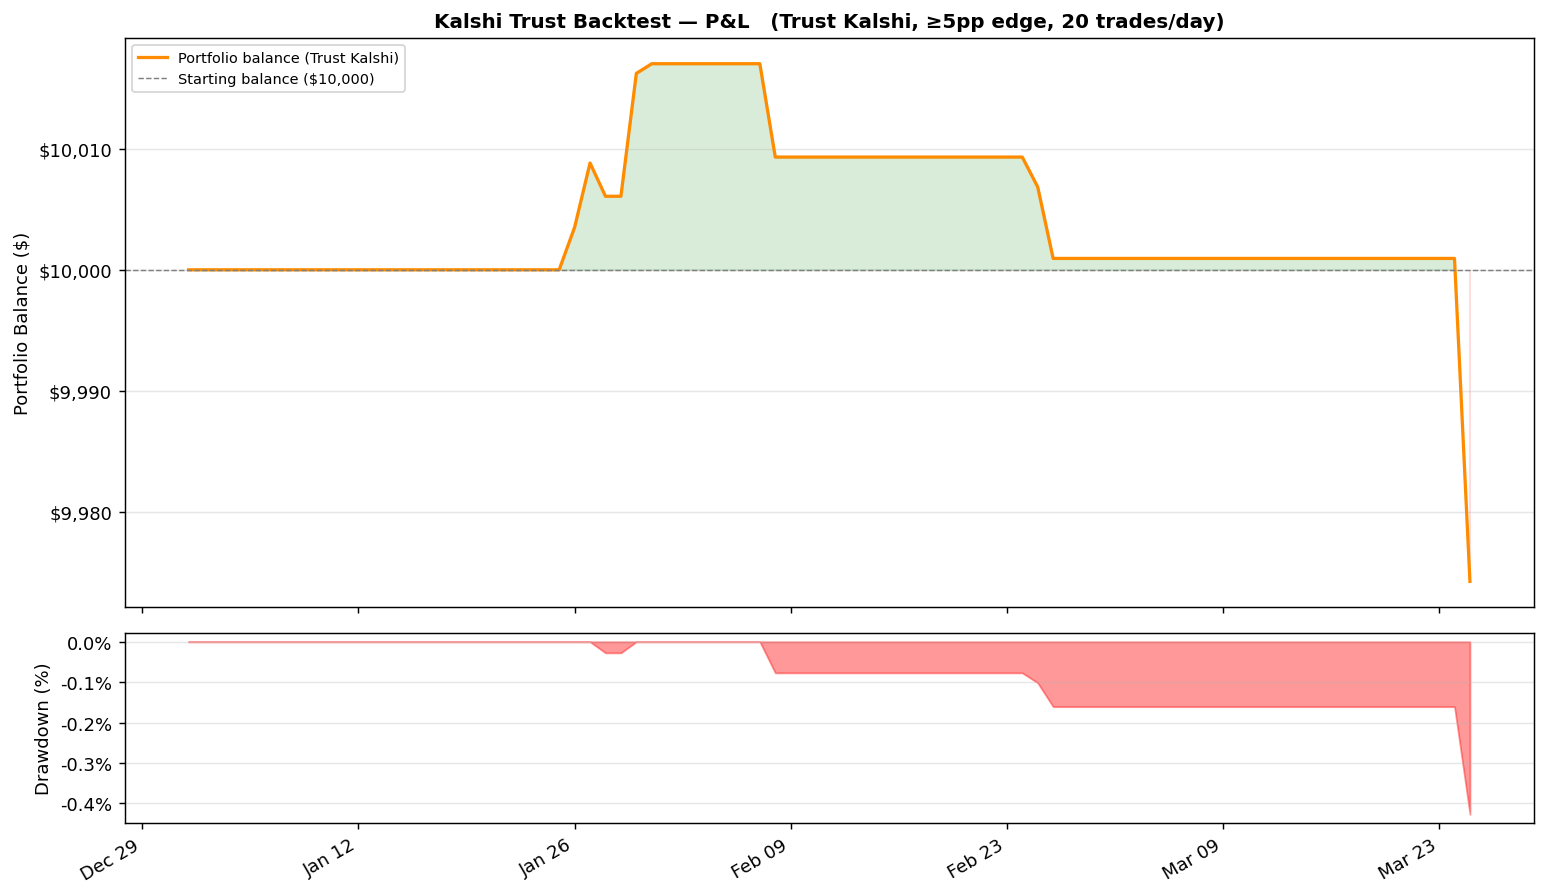

In [9]:
# ── Chart 1: Cumulative P&L ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax1, ax2 = axes

ax1.plot(bal_df['date'], bal_df['balance'], color='darkorange', linewidth=1.8,
         label='Portfolio balance (Trust Kalshi)')
ax1.axhline(STARTING_BALANCE, color='grey', linewidth=0.8, linestyle='--',
            label=f'Starting balance (${STARTING_BALANCE:,.0f})')
ax1.fill_between(bal_df['date'], STARTING_BALANCE, bal_df['balance'],
                  where=bal_df['balance'] >= STARTING_BALANCE,
                  alpha=0.15, color='green')
ax1.fill_between(bal_df['date'], STARTING_BALANCE, bal_df['balance'],
                  where=bal_df['balance'] < STARTING_BALANCE,
                  alpha=0.15, color='red')
ax1.set_ylabel('Portfolio Balance ($)')
ax1.set_title('Kalshi Trust Backtest — P&L   (Trust Kalshi, ≥5pp edge, 20 trades/day)',
               fontsize=11, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.grid(axis='y', alpha=0.3)

ax2.fill_between(bal_df['date'], drawdown, 0, color='red', alpha=0.4)
ax2.set_ylabel('Drawdown (%)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('kalshi_trust_pnl.png', dpi=130, bbox_inches='tight')
plt.show()

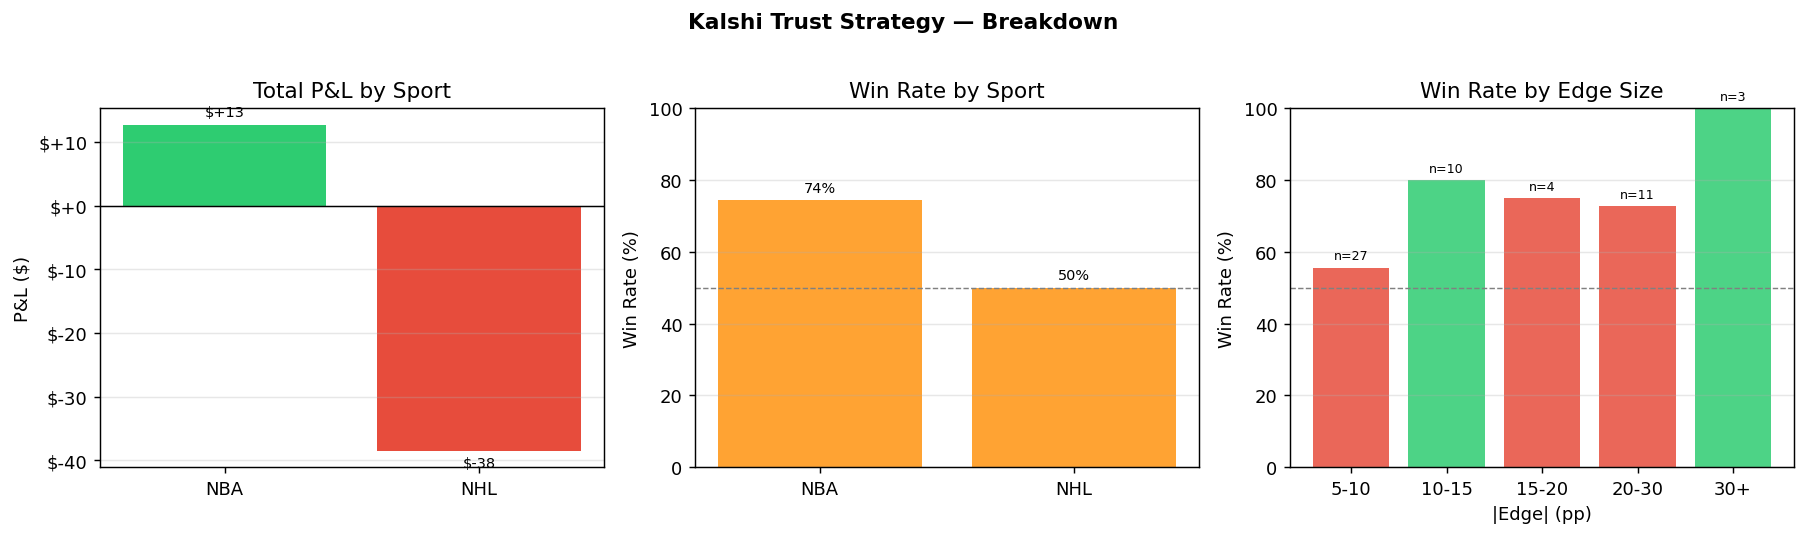


Per-sport summary:


,Trades,Wins,WinRate,TotalPnL,AvgPnL,AvgEdge
league,,,,,,
nba,39,29,74.0%,12.72,0.33,14.44
nhl,16,8,50.0%,-38.49,-2.41,12.54


In [10]:
# ── Chart 2: Breakdown ────────────────────────────────────────────────────────
if len(df) == 0:
    print('No trades to chart.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # P&L by sport
    ax = axes[0]
    sport_grp = df.groupby('league').agg(
        total_pnl=('pnl','sum'), n_trades=('pnl','count'), win_rate=('won','mean')
    ).sort_values('total_pnl', ascending=False)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sport_grp['total_pnl']]
    bars = ax.bar(sport_grp.index.str.upper(), sport_grp['total_pnl'], color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.bar_label(bars, fmt='${:+.0f}', padding=3, fontsize=8)
    ax.set_title('Total P&L by Sport')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax.grid(axis='y', alpha=0.3)

    # Win rate by sport
    ax = axes[1]
    wr = sport_grp['win_rate'] * 100
    bars2 = ax.bar(wr.index.str.upper(), wr, color='darkorange', alpha=0.8)
    ax.axhline(50, color='grey', linewidth=0.8, linestyle='--')
    ax.bar_label(bars2, fmt='%.0f%%', padding=3, fontsize=8)
    ax.set_title('Win Rate by Sport')
    ax.set_ylabel('Win Rate (%)')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

    # Edge vs win rate
    ax = axes[2]
    edge_bins = pd.cut(df['edge_pp'].abs(), bins=[5,10,15,20,30,100],
                        labels=['5-10','10-15','15-20','20-30','30+'])
    edge_grp = df.groupby(edge_bins, observed=False).agg(
        win_rate=('won','mean'), n_trades=('won','count'), avg_pnl=('pnl','mean')
    ).dropna()
    colors3 = ['#2ecc71' if v >= 0 else '#e74c3c' for v in edge_grp['avg_pnl']]
    ax.bar(edge_grp.index.astype(str), edge_grp['win_rate']*100, color=colors3, alpha=0.85)
    ax.axhline(50, color='grey', linewidth=0.8, linestyle='--')
    for i, (idx, row) in enumerate(edge_grp.iterrows()):
        ax.text(i, row['win_rate']*100+1.5, f"n={int(row['n_trades'])}",
                ha='center', va='bottom', fontsize=7)
    ax.set_title('Win Rate by Edge Size')
    ax.set_xlabel('|Edge| (pp)')
    ax.set_ylabel('Win Rate (%)')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Kalshi Trust Strategy — Breakdown', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('kalshi_trust_breakdown.png', dpi=130, bbox_inches='tight')
    plt.show()

    print('\nPer-sport summary:')
    summary = df.groupby('league').agg(
        Trades  =('pnl','count'),
        Wins    =('won','sum'),
        WinRate =('won','mean'),
        TotalPnL=('pnl','sum'),
        AvgPnL  =('pnl','mean'),
        AvgEdge =('edge_pp', lambda x: x.abs().mean()),
    ).round(2)
    summary['WinRate'] = (summary['WinRate']*100).round(1).astype(str)+'%'
    display(summary)

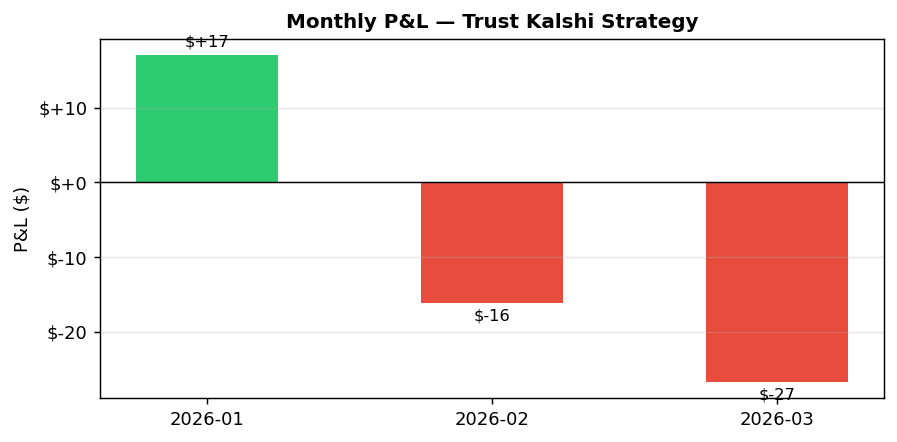

In [11]:
# ── Chart 3: Monthly P&L ──────────────────────────────────────────────────────
if len(df):
    df['month'] = pd.to_datetime(df['date']).dt.to_period('M').astype(str)
    monthly = df.groupby('month')['pnl'].sum()

    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors_m = ['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly]
    bars = ax.bar(monthly.index, monthly.values, color=colors_m, width=0.5)
    ax.bar_label(bars, fmt='${:+.0f}', padding=3, fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Monthly P&L — Trust Kalshi Strategy', fontsize=11, fontweight='bold')
    ax.set_ylabel('P&L ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:+,.0f}'))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('kalshi_trust_monthly.png', dpi=130, bbox_inches='tight')
    plt.show()

## Notes
- **Strategy direction:** This notebook follows Kalshi's signal. The [original backtest](backtest.ipynb) fades it.
- **Looser filter (5pp, 20 trades/day):** Captures many more opportunities but also more noise — markets with small edges that the model may not be equipped to evaluate.
- **Tennis caution:** Current rankings are used as a historical proxy; early-season matches may have higher error.
- **Inference:** If win rate here is substantially higher than in the fade-Kalshi notebook, it suggests Kalshi prices carry genuine information beyond what the ESPN model captures.